Cameron Barlow

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

I first just want to make sure I get a data frame that just has just UVA gifts.

In [2]:
foreign_gifts = pd.read_csv('ForeignGifts_edu.csv')

In [3]:
uva = foreign_gifts[foreign_gifts['Institution Name'] == 'University of Virginia']

In [4]:
uva.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 26235 to 26332
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          98 non-null     int64
 1   OPEID                       98 non-null     int64
 2   Institution Name            98 non-null     str  
 3   City                        98 non-null     str  
 4   State                       98 non-null     str  
 5   Foreign Gift Received Date  98 non-null     int64
 6   Foreign Gift Amount         98 non-null     int64
 7   Gift Type                   98 non-null     str  
 8   Country of Giftor           98 non-null     str  
 9   Giftor Name                 98 non-null     str  
dtypes: int64(4), str(6)
memory usage: 7.8 KB


In [5]:
uva['Foreign Gift Amount'].sum()

np.int64(22189238)

UVA has gotten about 22 million as a whole, which is above the median amount as seen from the initial analysis.

I first want to see what country is giving UVA the most money.

In [6]:
money_by_country = uva[['Foreign Gift Amount', 'Country of Giftor']].groupby('Country of Giftor').sum().sort_values(by='Foreign Gift Amount', ascending=True)

In [7]:
money_by_country

,Foreign Gift Amount
Country of Giftor,
FRANCE,250383
JAPAN,265970
RWANDA,284135
ISRAEL,623655
THE NETHERLANDS,725670
SINGAPORE,805000
KOREA,862787
BERMUDA,900000
FINLAND,1008384


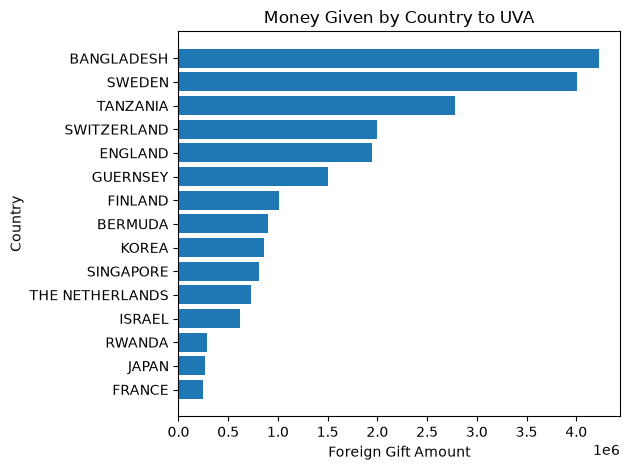

In [8]:
plt.barh(money_by_country.index, money_by_country['Foreign Gift Amount'])

plt.title('Money Given by Country to UVA')

plt.xlabel('Foreign Gift Amount')

plt.ylabel('Country')

plt.tight_layout()
plt.show()

The above plot shows we are getting a lot of money from Bangladesh and Sweden, as well as many other European nations. It certainly seems like a lot of our foreign money is coming from the continents of Europe and Asia. Just one initial observation in looking at this though is that both Qatar and China are not giving to UVA, which they are heavy givers.

I now want to explore the types of gifts UVA is getting.

In [9]:
uva['Gift Type'].value_counts()

Gift Type
Contract         64
Monetary Gift    34
Name: count, dtype: int64

This also raises some thoughts to me because we only have monetary gift types and contract. Real estate is not seen on here, which does seem to raise a lot of money as found in the initial analysis as well.

Now, I would like to compare UVA to some other peer institutions. For the sake of this, I believe peer institutions are ones in UVA's conference, the ACC. Thus, I will pick out schools like Duke, Boston College, Wake Forest, Notre Dame, and Clemson.

In [10]:
acc_schools = foreign_gifts[foreign_gifts['Institution Name'].isin(['University of Virginia','Duke University','Boston College','Wake Forest University','University of Notre Dame','Clemson University'])]

In [11]:
acc_schools['Institution Name'].value_counts()

Institution Name
Duke University             145
University of Notre Dame    122
University of Virginia       98
Clemson University           94
Boston College               21
Wake Forest University        4
Name: count, dtype: int64

In [12]:
money_by_institution = acc_schools[['Foreign Gift Amount', 'Institution Name']].groupby('Institution Name').sum().sort_values(by='Foreign Gift Amount', ascending=True)

In [13]:
money_by_institution

,Foreign Gift Amount
Institution Name,
Clemson University,4912287
Wake Forest University,5026211
University of Virginia,22189238
University of Notre Dame,46652439
Boston College,48995451
Duke University,343699498


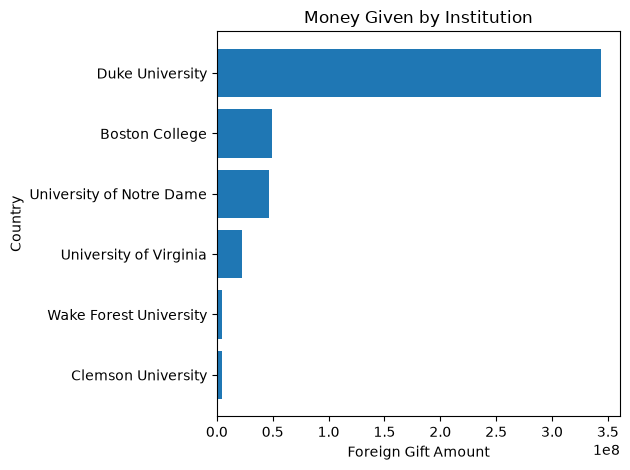

In [14]:
plt.barh(money_by_institution.index, money_by_institution['Foreign Gift Amount'])

plt.title('Money Given by Institution')

plt.xlabel('Foreign Gift Amount')

plt.ylabel('Country')

plt.tight_layout()
plt.show()

In looking at this, one aspect that stands out to me is that even though Boston College has way less gifts to them, with only 21 as compared to UVA having 98, Boston College has gotten more money than us. Because of this, I would like to look into them a little more to see what we could do differently.

In [15]:
bc = acc_schools[acc_schools['Institution Name'] == 'Boston College']

In [16]:
bc['Gift Type'].value_counts()

Gift Type
Monetary Gift    15
Contract          6
Name: count, dtype: int64

In [17]:
money_by_country_bc = bc[['Foreign Gift Amount', 'Country of Giftor']].groupby('Country of Giftor').sum().sort_values(by='Foreign Gift Amount', ascending=True)

In [18]:
money_by_country_bc

,Foreign Gift Amount
Country of Giftor,
ENGLAND,288247
CAYMAN ISLANDS (THE),333566
SOUTH KOREA,500000
BELGIUM,512921
SWITZERLAND,750000
DENMARK,1949859
ITALY,2999925
IRELAND,4877884
CHINA,5025000


Just in looking at this table, I can already see that China makes an appearance with Boston College, which is a country that is lacking from the giftors of UVA. Also, it seems that the Netherlands has given Boston College a ton of money, and we have gotten money from them as well. However, the Netherlands has given Boston College way more money than us, 31758049 as compared to 725670.

**Proposal:** In doing this, it is clear to me that we need to try and get some more money from the Netherlands. Especially since we already have contacts with them as they have already given us money, maybe we should try and get more from them. Furthermore, we should try our best to get money from China and Qatar, especially since these countries give the most money in total. Thus, we should target these countries because they have given a lot of money. Lastly, we should try and get a country to give us money for real estate, as these types of purchases seem to bring in the most money as well.